# Tutorial 4: Comparison between TensorFlow and PytorchGeometric on the SchNet Arquitecture

## Pytorch Geometric

In [ ]:
import argparse
import os.path as osp
import numpy as np
import torch
from tqdm import tqdm
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SchNet
import torch.nn as nn

In [ ]:
path = '/content/qm9/'
path = './' #path de cluster
dataset = QM9(path)

print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Dataset: QM9(130831):
Number of graphs: 130831
Number of features: 11
Number of classes: 19


De forma grafica se muestra una molecula del dataset, en este caso la que esta en el indice 121.



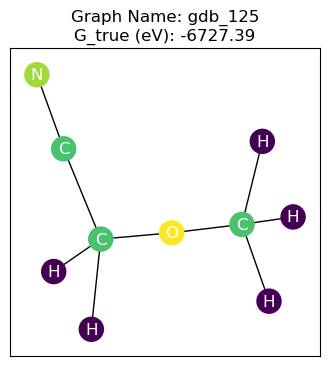

In [ ]:
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
atomic_symbols = {
    1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 10: 'Ne',
    11: 'Na', 12: 'Mg', 13: 'Al', 14: 'Si', 15: 'P', 16: 'S', 17: 'Cl', 18: 'Ar',
    19: 'K', 20: 'Ca'
}
data = dataset[121]
def visualize_graph(G, data, node_labels):
    plt.figure(figsize=(4,4))
    plt.xticks([])
    plt.yticks([])
    node_colors = data.x.numpy()[:, 5]

    pos = nx.spring_layout(G, seed=42)
    nodes = nx.draw_networkx_nodes(G, pos=nx.spring_layout(G, seed=42), node_color=node_colors)
    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12, font_color='white')
    plt.title(f"Graph Name: {data.name}\nG_true (eV): {np.round(data.y.numpy()[0,10], 2):.2f}")
    plt.show()

# Convertir el gráfico a NetworkX
G = to_networkx(data, to_undirected=True)
# Crear etiquetas para los nodos (usando el número atómico en este caso)
node_labels = {i: atomic_symbols.get(int(data.x[i, 5].item()), '?') for i in range(data.num_nodes)}

visualize_graph(G, data, node_labels)

Se crea un funcion run para ejecutar de forma iterativa el entrenamiento de la red

In [ ]:
global target_mean, target_std
def run(hidden_channels=64, num_filters=64, num_interactions=6, num_gaussians=300,
        cutoff = 30.0, lr=1e-3, num_epochs=200):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_dataset, val_dataset, test_dataset = dataset[:110000],\
                                               dataset[110000:120000],\
                                               dataset[120000:len(dataset)]
    #train_dataset, val_dataset, test_dataset = dataset[:3000], dataset[3000:4000], dataset[4000:5000]
    target_mean, target_std = train_dataset.mean(target=10), train_dataset.std(target=10)
    net = SchNet(
                hidden_channels=hidden_channels, #embedding layer
                num_filters=num_filters, #channels
                num_interactions=num_interactions, #capas de interaccion
                num_gaussians=num_gaussians,
                cutoff=cutoff
            )
    model = net.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer=optimizer, gamma=0.99)
    loss_mse = nn.MSELoss(reduction='mean')
    loss_mae = nn.L1Loss()

    train_loader = DataLoader(train_dataset, batch_size=200, shuffle=True) #before 100
    val_loader = DataLoader(val_dataset, batch_size=200, shuffle=True) #before 100
    test_loader = DataLoader(test_dataset, batch_size=200, shuffle=True) #before 100

    def train(data_loader):
        model.train()
        total_loss_mse, total_loss_mae = 0, 0
        for idx, batch in enumerate(data_loader):
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.z, batch.pos, batch.batch)
            norm_vals = (batch.y[:,10]-target_mean)/target_std
            loss = loss_mse(out, norm_vals.unsqueeze(-1))
            loss2 = loss_mae((out*target_std)+target_mean, batch.y[:, 10].unsqueeze(-1))
            loss.backward()
            optimizer.step()
            total_loss_mse += loss.item()
            total_loss_mae += loss2.item()
        return total_loss_mse / len(data_loader), total_loss_mae / len(data_loader)

    def test(data_loader, val=True):
        model.eval()
        total_loss_mse, total_loss_mae = 0, 0
        with torch.no_grad():
            for idx, batch in enumerate(data_loader):
                batch = batch.to(device)
                out = model(batch.z, batch.pos, batch.batch)
                if val:
                    norm_vals = (batch.y[:,10]-target_mean)/target_std
                    loss = loss_mse(out, norm_vals.unsqueeze(-1))
                else:
                    loss = loss_mse((out*target_std)+target_mean, batch.y[:, 10].unsqueeze(-1))
                loss2 = loss_mae((out*target_std)+target_mean, batch.y[:, 10].unsqueeze(-1))
                total_loss_mse += loss.item()
                total_loss_mae += loss2.item()
        return total_loss_mse / len(data_loader), total_loss_mae / len(data_loader)

    history = {'train_mse':[], 'val_mse':[], 'train_mae':[], 'val_mae':[]}
    for epoch in range(1, num_epochs+1):
        loss_train, loss2_train = train(train_loader)
        loss_val, loss2_val = test(val_loader,val=True)
        lr_scheduler.step()

        history['train_mse'].append(loss_train)
        history['val_mse'].append(loss_val)
        history['train_mae'].append(loss2_train)
        history['val_mae'].append(loss2_val)

        print(f'Epoch: {epoch:03d} Train(MSE) {loss_train:.2e} Val(MSE) {loss_val:.2e} Train(MAE) {loss2_train:.2f} Val(MAE) {loss2_val:.2f}')

        torch.cuda.empty_cache()

    loss_test, loss2_test = test(test_loader,val=False)
    print(f'Test(MSE) {loss_test:.2e}, Test(MAE) {loss2_test:.2f}')
    return history, loss_test, loss2_test

interactions blocks 3
Epoch: 001 Train(MSE) 5.55e-01 Val(MSE) 2.62e-02 Train(MAE) 342.57 Val(MAE) 132.67
Epoch: 002 Train(MSE) 2.75e-02 Val(MSE) 9.43e-03 Train(MAE) 107.45 Val(MAE) 81.61
Epoch: 003 Train(MSE) 2.61e-02 Val(MSE) 1.98e-02 Train(MAE) 103.24 Val(MAE) 135.60
Epoch: 004 Train(MSE) 1.61e-02 Val(MSE) 4.63e-03 Train(MAE) 86.77 Val(MAE) 55.49
Epoch: 005 Train(MSE) 1.71e-02 Val(MSE) 5.39e-03 Train(MAE) 94.60 Val(MAE) 63.03
Test(MSE) 3.05e+04, Test(MAE) 151.43


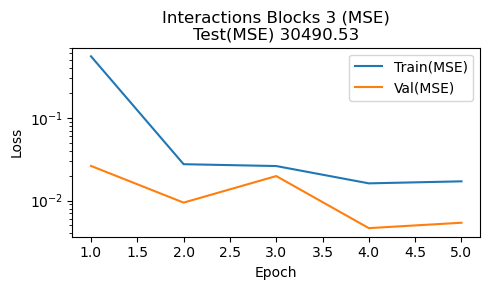

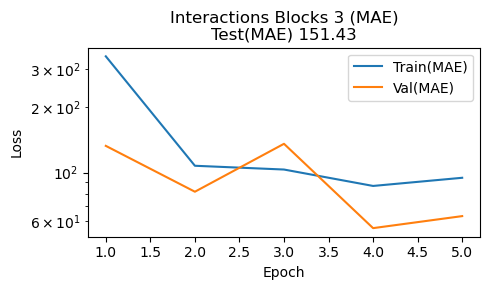

In [ ]:
#Variar interactions blocks
for val in [3]:
    print(f'interactions blocks {val}')
    history, loss_test, loss2_test = run(num_interactions=val, num_epochs=5)
    plt.figure(figsize=(5,3))
    plt.plot(range(1,len(history['train_mse'])+1),history['train_mse'],label='Train(MSE)')
    plt.plot(range(1,len(history['val_mse'])+1),history['val_mse'],label='Val(MSE)')
    plt.yscale('log'); plt.ylabel('Loss'); plt.xlabel('Epoch')
    plt.title(f'Interactions Blocks {val} (MSE)\nTest(MSE) {loss_test:.2f}')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'history_intblocksMSE_test.png')

    plt.figure(figsize=(5,3))
    plt.plot(range(1,len(history['train_mae'])+1),history['train_mae'],label='Train(MAE)')
    plt.plot(range(1,len(history['val_mae'])+1),history['val_mae'],label='Val(MAE)')
    plt.yscale('log'); plt.ylabel('Loss'); plt.xlabel('Epoch')
    plt.title(f'Interactions Blocks {val} (MAE)\nTest(MAE) {loss2_test:.2f}')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'history_intblocksMAE_test.png')

interactions blocks 6
Epoch: 001 Train(MSE) 2.43e+00 Val(MSE) 4.41e-02 Train(MAE) 597.62 Val(MAE) 171.18
Epoch: 002 Train(MSE) 4.44e-02 Val(MSE) 2.07e-02 Train(MAE) 141.51 Val(MAE) 117.46
Epoch: 003 Train(MSE) 2.45e-02 Val(MSE) 1.03e-02 Train(MAE) 100.80 Val(MAE) 83.53
Epoch: 004 Train(MSE) 1.72e-02 Val(MSE) 1.26e-02 Train(MAE) 85.96 Val(MAE) 93.90
Epoch: 005 Train(MSE) 1.35e-02 Val(MSE) 1.87e-02 Train(MAE) 77.20 Val(MAE) 118.39
Epoch: 006 Train(MSE) 1.22e-02 Val(MSE) 2.77e-02 Train(MAE) 76.93 Val(MAE) 161.08
Epoch: 007 Train(MSE) 1.23e-02 Val(MSE) 3.56e-03 Train(MAE) 80.70 Val(MAE) 48.65
Epoch: 008 Train(MSE) 1.29e-02 Val(MSE) 7.67e-03 Train(MAE) 84.61 Val(MAE) 78.00
Epoch: 009 Train(MSE) 1.12e-02 Val(MSE) 1.37e-02 Train(MAE) 79.91 Val(MAE) 109.55
Epoch: 010 Train(MSE) 1.08e-02 Val(MSE) 1.79e-02 Train(MAE) 79.08 Val(MAE) 132.63
Epoch: 011 Train(MSE) 1.12e-02 Val(MSE) 1.23e-02 Train(MAE) 75.49 Val(MAE) 108.30
Epoch: 012 Train(MSE) 7.93e-03 Val(MSE) 8.77e-03 Train(MAE) 69.54 Val(MAE) 87

Epoch: 102 Train(MSE) 2.12e-04 Val(MSE) 3.96e-04 Train(MAE) 11.99 Val(MAE) 19.68
Epoch: 103 Train(MSE) 2.26e-04 Val(MSE) 5.09e-05 Train(MAE) 11.18 Val(MAE) 6.53
Epoch: 104 Train(MSE) 3.37e-04 Val(MSE) 8.15e-05 Train(MAE) 12.06 Val(MAE) 8.07
Epoch: 105 Train(MSE) 1.21e-04 Val(MSE) 9.22e-05 Train(MAE) 8.51 Val(MAE) 8.80
Epoch: 106 Train(MSE) 1.99e-04 Val(MSE) 3.03e-03 Train(MAE) 10.71 Val(MAE) 53.77
Epoch: 107 Train(MSE) 2.08e-04 Val(MSE) 9.26e-05 Train(MAE) 9.64 Val(MAE) 9.19
Epoch: 108 Train(MSE) 1.84e-04 Val(MSE) 6.42e-05 Train(MAE) 10.83 Val(MAE) 7.34
Epoch: 109 Train(MSE) 1.83e-04 Val(MSE) 3.61e-05 Train(MAE) 10.39 Val(MAE) 5.27
Epoch: 110 Train(MSE) 1.78e-04 Val(MSE) 2.00e-05 Train(MAE) 9.68 Val(MAE) 3.71
Epoch: 111 Train(MSE) 1.39e-04 Val(MSE) 1.31e-04 Train(MAE) 9.53 Val(MAE) 10.74
Epoch: 112 Train(MSE) 1.51e-04 Val(MSE) 2.02e-05 Train(MAE) 10.00 Val(MAE) 3.69
Epoch: 113 Train(MSE) 2.04e-04 Val(MSE) 5.81e-05 Train(MAE) 10.22 Val(MAE) 7.08
Epoch: 114 Train(MSE) 1.23e-04 Val(MSE) 4

Epoch: 206 Train(MSE) 2.40e-05 Val(MSE) 2.00e-05 Train(MAE) 3.98 Val(MAE) 4.19
Epoch: 207 Train(MSE) 2.40e-05 Val(MSE) 6.89e-06 Train(MAE) 3.69 Val(MAE) 2.15
Epoch: 208 Train(MSE) 2.77e-05 Val(MSE) 8.53e-05 Train(MAE) 4.17 Val(MAE) 9.12
Epoch: 209 Train(MSE) 2.01e-05 Val(MSE) 5.70e-06 Train(MAE) 3.53 Val(MAE) 1.92
Epoch: 210 Train(MSE) 2.32e-05 Val(MSE) 1.61e-05 Train(MAE) 3.79 Val(MAE) 3.68
Epoch: 211 Train(MSE) 2.02e-05 Val(MSE) 1.09e-05 Train(MAE) 3.69 Val(MAE) 2.93
Epoch: 212 Train(MSE) 2.31e-05 Val(MSE) 3.97e-06 Train(MAE) 3.75 Val(MAE) 1.58
Epoch: 213 Train(MSE) 2.41e-05 Val(MSE) 4.68e-06 Train(MAE) 3.82 Val(MAE) 1.77
Epoch: 214 Train(MSE) 1.84e-05 Val(MSE) 6.16e-06 Train(MAE) 3.45 Val(MAE) 2.03
Epoch: 215 Train(MSE) 2.06e-05 Val(MSE) 2.68e-05 Train(MAE) 3.71 Val(MAE) 5.04
Epoch: 216 Train(MSE) 1.70e-05 Val(MSE) 1.10e-05 Train(MAE) 3.38 Val(MAE) 2.98
Epoch: 217 Train(MSE) 2.42e-05 Val(MSE) 4.76e-06 Train(MAE) 3.61 Val(MAE) 1.76
Epoch: 218 Train(MSE) 1.97e-05 Val(MSE) 5.48e-06 Tra

Epoch: 310 Train(MSE) 4.51e-06 Val(MSE) 2.18e-06 Train(MAE) 1.72 Val(MAE) 1.16
Epoch: 311 Train(MSE) 4.84e-06 Val(MSE) 2.43e-06 Train(MAE) 1.76 Val(MAE) 1.27
Epoch: 312 Train(MSE) 4.40e-06 Val(MSE) 2.39e-06 Train(MAE) 1.69 Val(MAE) 1.25
Epoch: 313 Train(MSE) 4.90e-06 Val(MSE) 1.97e-06 Train(MAE) 1.76 Val(MAE) 1.11
Epoch: 314 Train(MSE) 4.28e-06 Val(MSE) 1.83e-06 Train(MAE) 1.68 Val(MAE) 1.06
Epoch: 315 Train(MSE) 4.31e-06 Val(MSE) 2.66e-06 Train(MAE) 1.68 Val(MAE) 1.34
Epoch: 316 Train(MSE) 5.05e-06 Val(MSE) 3.10e-06 Train(MAE) 1.72 Val(MAE) 1.45
Epoch: 317 Train(MSE) 4.81e-06 Val(MSE) 2.19e-06 Train(MAE) 1.74 Val(MAE) 1.21
Epoch: 318 Train(MSE) 4.21e-06 Val(MSE) 4.98e-06 Train(MAE) 1.64 Val(MAE) 1.95
Epoch: 319 Train(MSE) 4.25e-06 Val(MSE) 5.16e-06 Train(MAE) 1.67 Val(MAE) 2.03
Epoch: 320 Train(MSE) 4.02e-06 Val(MSE) 3.19e-06 Train(MAE) 1.62 Val(MAE) 1.51
Epoch: 321 Train(MSE) 4.20e-06 Val(MSE) 4.47e-06 Train(MAE) 1.65 Val(MAE) 1.79
Epoch: 322 Train(MSE) 3.70e-06 Val(MSE) 6.67e-06 Tra

Epoch: 414 Train(MSE) 1.68e-06 Val(MSE) 1.38e-06 Train(MAE) 1.03 Val(MAE) 0.93
Epoch: 415 Train(MSE) 1.62e-06 Val(MSE) 1.30e-06 Train(MAE) 1.02 Val(MAE) 0.90
Epoch: 416 Train(MSE) 1.70e-06 Val(MSE) 1.38e-06 Train(MAE) 1.05 Val(MAE) 0.93
Epoch: 417 Train(MSE) 1.69e-06 Val(MSE) 1.32e-06 Train(MAE) 1.04 Val(MAE) 0.91
Epoch: 418 Train(MSE) 1.68e-06 Val(MSE) 2.31e-06 Train(MAE) 1.04 Val(MAE) 1.28
Epoch: 419 Train(MSE) 1.58e-06 Val(MSE) 1.39e-06 Train(MAE) 1.00 Val(MAE) 0.93
Epoch: 420 Train(MSE) 1.75e-06 Val(MSE) 1.66e-06 Train(MAE) 1.06 Val(MAE) 1.05
Epoch: 421 Train(MSE) 1.63e-06 Val(MSE) 1.94e-06 Train(MAE) 1.02 Val(MAE) 1.16
Epoch: 422 Train(MSE) 1.52e-06 Val(MSE) 1.47e-06 Train(MAE) 0.98 Val(MAE) 0.97
Epoch: 423 Train(MSE) 1.55e-06 Val(MSE) 4.47e-06 Train(MAE) 0.99 Val(MAE) 1.92
Epoch: 424 Train(MSE) 1.56e-06 Val(MSE) 1.31e-06 Train(MAE) 1.00 Val(MAE) 0.90
Epoch: 425 Train(MSE) 1.60e-06 Val(MSE) 1.35e-06 Train(MAE) 1.01 Val(MAE) 0.91
Epoch: 426 Train(MSE) 1.55e-06 Val(MSE) 1.36e-06 Tra

Epoch: 518 Train(MSE) 1.02e-06 Val(MSE) 1.27e-06 Train(MAE) 0.79 Val(MAE) 0.91
Epoch: 519 Train(MSE) 1.03e-06 Val(MSE) 1.42e-06 Train(MAE) 0.80 Val(MAE) 0.97
Epoch: 520 Train(MSE) 1.03e-06 Val(MSE) 1.08e-06 Train(MAE) 0.80 Val(MAE) 0.81
Epoch: 521 Train(MSE) 1.05e-06 Val(MSE) 1.08e-06 Train(MAE) 0.81 Val(MAE) 0.82
Epoch: 522 Train(MSE) 1.03e-06 Val(MSE) 1.02e-06 Train(MAE) 0.80 Val(MAE) 0.78
Epoch: 523 Train(MSE) 1.01e-06 Val(MSE) 1.05e-06 Train(MAE) 0.79 Val(MAE) 0.80
Epoch: 524 Train(MSE) 1.01e-06 Val(MSE) 1.22e-06 Train(MAE) 0.79 Val(MAE) 0.87
Epoch: 525 Train(MSE) 1.00e-06 Val(MSE) 1.11e-06 Train(MAE) 0.79 Val(MAE) 0.82
Epoch: 526 Train(MSE) 1.05e-06 Val(MSE) 1.11e-06 Train(MAE) 0.81 Val(MAE) 0.83
Epoch: 527 Train(MSE) 1.02e-06 Val(MSE) 1.04e-06 Train(MAE) 0.80 Val(MAE) 0.79
Epoch: 528 Train(MSE) 1.01e-06 Val(MSE) 1.03e-06 Train(MAE) 0.79 Val(MAE) 0.79
Epoch: 529 Train(MSE) 1.00e-06 Val(MSE) 1.03e-06 Train(MAE) 0.79 Val(MAE) 0.79
Epoch: 530 Train(MSE) 1.00e-06 Val(MSE) 1.06e-06 Tra

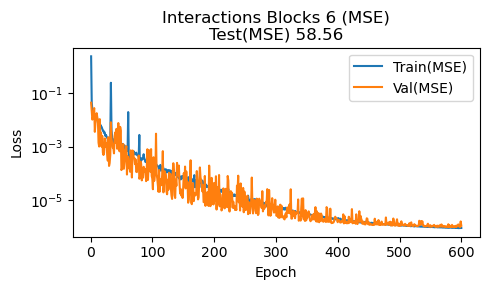

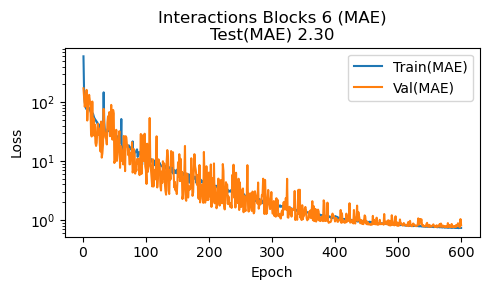

In [ ]:
#Variar interactions blocks for example
for val in [6]:

    print(f'interactions blocks {val}')
    history, loss_test, loss2_test = run(num_interactions=val, num_epochs=600)
    plt.figure(figsize=(5,3))
    plt.plot(range(1,len(history['train_mse'])+1),history['train_mse'],label='Train(MSE)')
    plt.plot(range(1,len(history['val_mse'])+1),history['val_mse'],label='Val(MSE)')
    plt.yscale('log'); plt.ylabel('Loss'); plt.xlabel('Epoch')
    plt.title(f'Interactions Blocks {val} (MSE)\nTest(MSE) {loss_test:.2f}')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'history_intblocks{val}_MSE.png')

    plt.figure(figsize=(5,3))
    plt.plot(range(1,len(history['train_mae'])+1),history['train_mae'],label='Train(MAE)')
    plt.plot(range(1,len(history['val_mae'])+1),history['val_mae'],label='Val(MAE)')
    plt.yscale('log'); plt.ylabel('Loss'); plt.xlabel('Epoch')
    plt.title(f'Interactions Blocks {val} (MAE)\nTest(MAE) {loss2_test:.2f}')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'history_intblocks{val}_MAE.png')

## TensorFlow

In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.8 MB/s eta 0:00:00


In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import tensorflow as tf
import pandas as pd
import networkx as nx
from torch_geometric.datasets import QM9

In [4]:
path = './'
dataset = QM9(path)

print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

train_dataset, test_dataset = dataset[:120000],\
                              dataset[120000:len(dataset)]

Extracting ./raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


Dataset: QM9(130831):
Number of graphs: 130831
Number of features: 11
Number of classes: 19


/usr/local/lib/python3.10/dist-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


,G (train)
count,130831.000000
mean,-11179.875977
std,1085.403931
min,-19445.314453
25%,-11916.187500
50%,-11342.830078
75%,-10532.833984
max,-1102.022949


/usr/local/lib/python3.10/dist-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


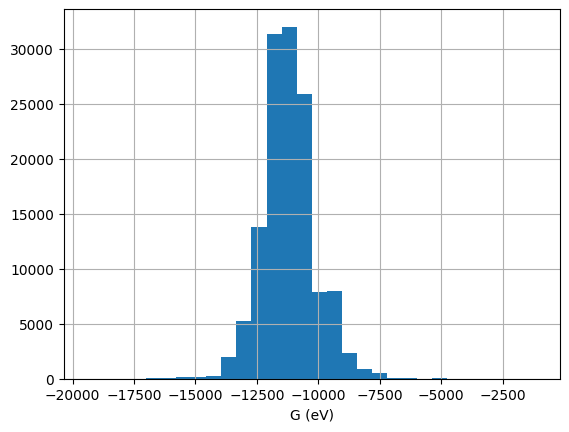

In [5]:
G_train = pd.Series(train_dataset.data.y[:,10].numpy(), name='G (train) ')
stats_G_train = G_train.describe()
display(G_train.describe())

G_test = pd.Series(test_dataset.data.y[:,10].numpy(), name='G (test)')
stats_G_test = G_test.describe()

ax = G_train.hist(bins=30)
_ = ax.set_xlabel('G (eV)')

def norm_energy(val,stats):
    return (val-stats.mean())/stats.std()

def unnorm_energy(val,stats):
    return val*stats.std()+stats.mean()

In [6]:
def generator():
      for j in range(len(train_dataset)):
            G = np.array([train_dataset[j].y.numpy()[0][10]])
            yield train_dataset[j].pos.numpy(), train_dataset[j].z.numpy(), norm_energy(G, stats_G_train)

def generator_test():
      for j in range(len(test_dataset)):
            G = np.array([test_dataset[j].y.numpy()[0][10]])
            yield test_dataset[j].pos.numpy(), test_dataset[j].z.numpy(), G

data = tf.data.Dataset.from_generator(
    generator,
    output_signature=(
        tf.TensorSpec(shape=(None, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
        tf.TensorSpec(shape=(1), dtype=tf.float32)
    ),
).shuffle(
    1000,
    reshuffle_each_iteration=False,
)
test_data = tf.data.Dataset.from_generator(
    generator_test,
    output_signature=(
        tf.TensorSpec(shape=(None, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
        tf.TensorSpec(shape=(1), dtype=tf.float32)
    ),
).shuffle(
    1000,
    reshuffle_each_iteration=False,
)

train_data = data.take(110000)
val_data = data.skip(110000).take(10000)

Cambiar de dataset a graph dataset

In [7]:

def get_edges(positions, NN, sorted=True):
    M = tf.shape(input=positions)[0] #number of points
    # adjust NN
    NN = tf.minimum(NN, M)
    qexpand = tf.expand_dims(positions, 1)  # add dim extra at 1
    qTexpand = tf.expand_dims(positions, 0)  # add dim extra at 0
    # repeat it to make matrix of all positions
    qtile = tf.tile(qexpand, [1, M, 1]) #repeat M times
    qTtile = tf.tile(qTexpand, [M, 1, 1])
    # subtract them to get distance matrix
    dist_mat = qTtile - qtile
    # mask distance matrix to remove zros (self-interactions)
    dist = tf.norm(tensor=dist_mat, axis=2)
    mask = dist >= 5e-4
    mask_cast = tf.cast(mask, dtype=dist.dtype) #matriz 0 y 1
    # make masked things be really far
    dist_mat_r = dist * mask_cast + (1 - mask_cast) * 1000
    topk = tf.math.top_k(-dist_mat_r, k=NN, sorted=sorted)
    return -topk.values, topk.indices

MAX_DEGREE = 30 #cantidad de vecinos a un atomo dado
EDGE_FEATURES = 300 #cantidad de caracteristicas por distancia
MAX_R = 30 #hiperparametro de rbf

gamma = 10
mu = np.linspace(0, MAX_R, EDGE_FEATURES)


def rbf(r):
    return tf.exp(-gamma * (r[..., tf.newaxis] - mu) ** 2)


def make_graph(x, y, z):
    edge_r, edge_i = get_edges(x, MAX_DEGREE)
    edge_features = rbf(edge_r)
    return (y, edge_features, edge_i), z

graph_train_data = train_data.map(make_graph)
graph_val_data = val_data.map(make_graph)
graph_test_data = test_data.map(make_graph)


In [8]:
def ssp(x):
    # shifted softplus activation
    return tf.math.log(0.5 * tf.math.exp(x) + 0.5)


def make_h1(units):
    return tf.keras.Sequential([tf.keras.layers.Dense(units)])


def make_h2(units):
    return tf.keras.Sequential(
        [tf.keras.layers.Dense(units, activation=ssp),
         tf.keras.layers.Dense(units, activation=ssp)])

def make_h3(units):
    return tf.keras.Sequential(
        [tf.keras.layers.Dense(units, activation=ssp), tf.keras.layers.Dense(units)]
    )

class SchNetModel(tf.keras.Model):
    """Implementation of SchNet Model"""

    def __init__(self, gnn_blocks, channels, **kwargs):
        super(SchNetModel, self).__init__(**kwargs)
        self.gnn_blocks = gnn_blocks

        # build our layers
        self.embedding = tf.keras.layers.Embedding(60, channels) #transform to 1 to channels
        self.h1s = [make_h1(channels) for _ in range(self.gnn_blocks)]
        self.h2s = [make_h2(channels) for _ in range(self.gnn_blocks)]
        self.h3s = [make_h3(channels) for _ in range(self.gnn_blocks)]
        self.readout_l1 = tf.keras.layers.Dense(channels // 2, activation=ssp)
        self.readout_l2 = tf.keras.layers.Dense(1)

    def call(self, inputs):
        nodes, edge_features, edge_i = inputs
        # turn node types as index to features
        nodes = self.embedding(nodes)
        for i in range(self.gnn_blocks):
            # get the node features per edge
            v_sk = tf.gather(nodes, edge_i) #choose closest atoms
            e_k = self.h1s[i](v_sk) * self.h2s[i](edge_features) #calculate directions of update atoms
            e_i = tf.reduce_sum(e_k, axis=1) #compute sum over all closest atoms
            nodes += self.h3s[i](e_i) #update node feature. The edge feature are not updated
        # readout now
        nodes = self.readout_l1(nodes)
        nodes = self.readout_l2(nodes)
        return tf.reduce_mean(nodes, axis=0) #invariant operation

In [9]:
small_schnet = SchNetModel(6, 64) #3 capas 64 canales

In [ ]:
small_schnet.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-3), loss='mse', metrics=['mae']
)
# Train your model
result = small_schnet.fit(graph_train_data, validation_data=graph_val_data, epochs=20)

Epoch 1/20
 109996/Unknown 774s 7ms/step - loss: 7.1763e-05 - mae: 0.0037

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


110000/110000 ━━━━━━━━━━━━━━━━━━━━ 862s 8ms/step - loss: 7.1760e-05 - mae: 0.0037 - val_loss: 9.9140e-08 - val_mae: 2.4897e-04
Epoch 2/20
110000/110000 ━━━━━━━━━━━━━━━━━━━━ 720s 7ms/step - loss: 2.3887e-05 - mae: 0.0021 - val_loss: 2.4695e-06 - val_mae: 0.0015
Epoch 3/20
110000/110000 ━━━━━━━━━━━━━━━━━━━━ 752s 7ms/step - loss: 2.1392e-05 - mae: 0.0020 - val_loss: 1.1160e-07 - val_mae: 2.7556e-04
Epoch 4/20
110000/110000 ━━━━━━━━━━━━━━━━━━━━ 729s 7ms/step - loss: 1.7104e-05 - mae: 0.0017 - val_loss: 1.3018e-07 - val_mae: 2.9344e-04
Epoch 5/20
110000/110000 ━━━━━━━━━━━━━━━━━━━━ 730s 7ms/step - loss: 1.5532e-05 - mae: 0.0016 - val_loss: 2.0154e-07 - val_mae: 4.1243e-04
Epoch 6/20
110000/110000 ━━━━━━━━━━━━━━━━━━━━ 744s 7ms/step - loss: 1.4671e-05 - mae: 0.0016 - val_loss: 2.5197e-07 - val_mae: 4.8344e-04
Epoch 7/20
110000/110000 ━━━━━━━━━━━━━━━━━━━━ 727s 7ms/step - loss: 1.7465e-05 - mae: 0.0017 - val_loss: 1.6099e-07 - val_mae: 3.1107e-04
Epoch 8/20
110000/110000 ━━━━━━━━━━━━━━━━━━━━ 727

In [ ]:
small_schnet.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-3), loss='mse', metrics=['mae']
)
# Train your model
result = small_schnet.fit(graph_train_data, validation_data=graph_val_data, epochs=100)

Epoch 1/100
110000/110000 [==============================] - 360s 3ms/step - loss: 7.7259e-06 - mae: 9.8515e-04 - val_loss: 1.4511e-06 - val_mae: 9.2553e-04
Epoch 2/100
110000/110000 [==============================] - 333s 3ms/step - loss: 4.7118e-06 - mae: 8.4157e-04 - val_loss: 1.1911e-06 - val_mae: 7.9767e-04
Epoch 3/100
110000/110000 [==============================] - 317s 3ms/step - loss: 4.5085e-06 - mae: 7.6707e-04 - val_loss: 1.8409e-06 - val_mae: 0.0011
Epoch 4/100
110000/110000 [==============================] - 320s 3ms/step - loss: 4.4310e-06 - mae: 7.1538e-04 - val_loss: 2.4190e-06 - val_mae: 0.0012
Epoch 5/100
110000/110000 [==============================] - 318s 3ms/step - loss: 4.3938e-06 - mae: 6.7574e-04 - val_loss: 3.2405e-06 - val_mae: 0.0015
Epoch 6/100
110000/110000 [==============================] - 322s 3ms/step - loss: 4.4520e-06 - mae: 6.4280e-04 - val_loss: 2.7712e-06 - val_mae: 0.0013
Epoch 7/100
110000/110000 [==============================] - 314s 3ms/step

In [ ]:
plt.plot(result.history["loss"], label="training loss")
plt.plot(result.history["val_loss"], label="validation loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
mae = 0
for i, (x, y) in enumerate(graph_test_data):
    yhat = unnorm_energy(small_schnet(x), stats_G_train)
    mae += abs(yhat[0] - y.numpy()[0])
print(f'MAE (Test set): {mae/(i+1)}')

In [ ]:
mae = 0
for i, (x, y) in enumerate(graph_train_data):
    yhat = unnorm_energy(small_schnet(x), stats_G_train)
    mae += abs(yhat[0] - y.numpy()[0])
print(f'MAE (Train set): {mae/(i+1)}')

mae = 0
for i, (x, y) in enumerate(graph_val_data):
    yhat = unnorm_energy(small_schnet(x), stats_G_train)
    mae += abs(yhat[0] - y.numpy()[0])
print(f'MAE (val set): {mae/(i+1)}')